In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import liana as li
from liana.method import cellphonedb, cellchat
from tqdm import tqdm
#liana dotplot returns a ggsave object...
from plotnine import ggsave, ggplot
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
folder = "../../ProcessedData/IndividualMiceData/"
Mice = ["GF_HF_6B","GF_HF_13L","SPF_HF_118","SPF_HF_131","SPF_HF_133","GF_HFVHC_5A","GF_HFVHC_16L","SPF_HFVHC_124","SPF_HFVHC_136","SPF_HFVHC_137"]
method = ["CellPhoneDB", "CellChat"]
def get_data():
    data = {}
    for mouse in tqdm(Mice):
        data[mouse] = {}
        for m in method:
            file = folder+mouse+"_"+m+".h5ad"
            data[mouse][m] = sc.read_h5ad(file)
    return data
data = get_data()
st = ['Mig. cDCs -> NK cells','ILC1s -> Endothelial cells','Hepatocytes -> T cells']
lr = ['Tgfa -> Erbb4', 'Col1a2 -> Itgb3', 'Lama5 -> Dag1']

100%|██████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:24<00:00,  2.43s/it]


In [3]:
st = ['Endothelial cells -> Neutrophils','Kupffer cells -> B cells','pDCs -> ILC1s']
lr = ['Apoe -> Sorl1','Cfh -> Itgam','Tgfb1 -> Cxcr4']
mouse_curr = list(data.keys())[0]
mouse_curr_data = {}
for m in method:
    x = data[mouse_curr][m].uns["cpdb_res"]
    if m == 'CellPhoneDB':
        x = x[x['lr_means'] != 0]
        x['Ligand_Value'] = x['ligand_means']
        x['Receptor_Value'] = x['receptor_means']
    else:
        x = x[x['lr_probs'] != 0]
        x['Ligand_Value'] = x['ligand_trimean']
        x['Receptor_Value'] = x['receptor_trimean']
    x = x[['ligand', 'receptor', 'source', 'target', 'Ligand_Value', 'Receptor_Value']]
    x['Source -> Target'] = x['source'] + ' -> ' + x['target']
    x['Ligand -> Receptor'] = x['ligand'] + ' -> ' + x['receptor']
    x = x[x['Source -> Target'].isin(st)]
    x = x[x['Ligand -> Receptor'].isin(lr)]
    mouse_curr_data[m] = x[['Source -> Target', 'Ligand -> Receptor','Ligand_Value', 'Receptor_Value']]
merged_df = pd.merge(mouse_curr_data[method[0]], mouse_curr_data[method[1]], on=['Source -> Target', 'Ligand -> Receptor'], how='inner', suffixes=('_CellPhoneDB', '_CellChat'))
merged_df

,Source -> Target,Ligand -> Receptor,Ligand_Value_CellPhoneDB,Receptor_Value_CellPhoneDB,Ligand_Value_CellChat,Receptor_Value_CellChat
0,Endothelial cells -> Neutrophils,Apoe -> Sorl1,1.420757,1.470048,0.403212,0.431047
1,Kupffer cells -> B cells,Apoe -> Sorl1,1.823094,0.954869,0.517453,0.292011
2,Endothelial cells -> Neutrophils,Tgfb1 -> Cxcr4,0.650888,1.063774,0.195548,0.343994
3,pDCs -> ILC1s,Apoe -> Sorl1,0.815683,0.662246,0.237504,0.194997
4,Endothelial cells -> Neutrophils,Cfh -> Itgam,0.452590,1.006060,0.126654,0.326522
5,Kupffer cells -> B cells,Tgfb1 -> Cxcr4,0.715512,0.509237,0.203325,0.143897


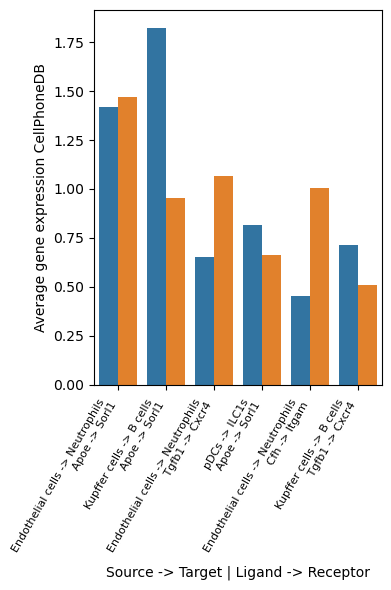

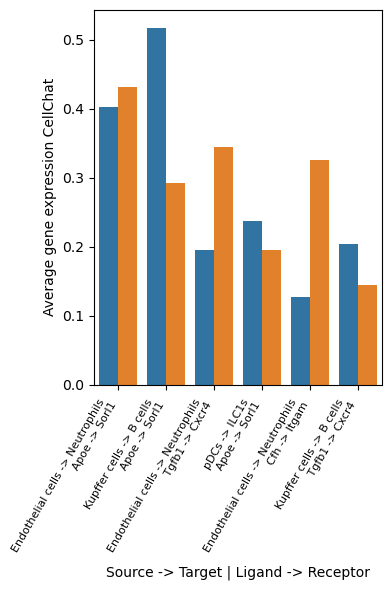

In [19]:
df_plot = merged_df.copy()

df_plot['Interaction'] = df_plot['Source -> Target'] + ' \n ' + df_plot['Ligand -> Receptor']

# --- Plot for CellPhoneDB values ---
# Melt the DataFrame to long format for CellPhoneDB
df_cellphonedb_melted = pd.melt(
    df_plot,
    id_vars=['Interaction'],
    value_vars=['Ligand_Value_CellPhoneDB', 'Receptor_Value_CellPhoneDB'],
    var_name='Value_Type',
    value_name='Value'
)

# Create the bar plot for CellPhoneDB
plt.figure(figsize=(4, 6))  # Increased figure size for better readability
sns.barplot(
    data=df_cellphonedb_melted,
    x='Interaction',
    y='Value',
    hue='Value_Type',
    dodge=True,
    legend=False
)
plt.xlabel('Source -> Target | Ligand -> Receptor')
plt.ylabel('Average gene expression CellPhoneDB')
# plt.title('CellPhoneDB Ligand and Receptor Values')
plt.xticks(rotation=60, fontsize=8, ha='right')  # Rotated and smaller x-axis labels
plt.tight_layout()
plt.savefig("CellPhoneDB_Mouse1_lr_values.png")
# plt.show()

# --- Plot for CellChat values ---
# Melt the DataFrame to long format for CellChat
df_cellchat_melted = pd.melt(
    df_plot,
    id_vars=['Interaction'],
    value_vars=['Ligand_Value_CellChat', 'Receptor_Value_CellChat'],
    var_name='Value_Type',
    value_name='Value'
)

# Create the bar plot for CellChat
plt.figure(figsize=(4, 6))  # Increased figure size for better readability
sns.barplot(
    data=df_cellchat_melted,
    x='Interaction',
    y='Value',
    hue='Value_Type',
    dodge=True,
    legend=False
)
plt.xlabel('Source -> Target | Ligand -> Receptor')
plt.ylabel('Average gene expression CellChat')
# plt.title('CellChat Ligand and Receptor Values')
plt.xticks(rotation=60, fontsize=8, ha='right')  # Rotated and smaller x-axis labels
plt.tight_layout()
plt.savefig("CellChat_Mouse1_lr_values.png")
# plt.show()